# APL case study: Boolean network analyses

This notebook explores the subset-minimal Boolean networks inferred by scBOLT for the PLZF-RARα APL case study. It documents the selected components, the structural properties of the inferred network ensemble, and the resulting attractor landscapes.

Each section introduces the corresponding modelling question and reproduces the analyses used to interpret the Boolean networks in the manuscript.

### Table of contents

1. [Data overview](#data)
2. [Structural properties](#structure)
3. [Gene selection enrichment analysis](#enrichment)
4. [Pairwise macrostate distances](#distances)
5. [Boolean-network diversity](#model-diversity)
6. [Reachable attractors](#attractors)
7. [Reference APL model attractors](#reference-model)
8. [Subset-minimal Boolean networks](#minimal)

### Figure index <a class="anchor" id="figure-index"></a>

The notebook exports the following figures. Links jump to the section where each figure is generated.

| Notebook section | Generated file |
| --- | --- |
| [Structural properties: function families](#fig-function-families) | `ig_function_families.pdf` |
| [Structural properties: feedback core](#fig-feedback-core) | `ig_feedback_core.pdf` |
| [Gene selection enrichment: top GO BP terms](#fig-goea-bp) | `bn_goea_bp_top20.pdf` |
| [Boolean-network diversity: MDS projection](#fig-model-mds) | `bn_mds.pdf` |
| [Reachable-attractor distributions](#fig-attractor-distributions) | `bn_attractor_distributions.pdf` |
| [Reference-model attractor comparison](#fig-reference-model) | `reference_model_state_comparison.pdf` |


### Notebook setup

In [1]:
%matplotlib inline

# Standard library

import gzip
import logging
import os
import shutil
import tempfile
import urllib.request
from collections import defaultdict
from itertools import combinations
from pathlib import Path

# Third-party packages

import bonesistools as bt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS
from goatools.obo_parser import GODag
from sklearn.cluster import KMeans
from sklearn.manifold import MDS

from IPython.display import display

# Global display and plotting settings

logging.getLogger("colomoto_jupyter").setLevel(logging.ERROR)
pd.set_option("future.no_silent_downcasting", True)
bt.omics.pl.set_default_params()

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

# Case-study directories


def find_project_root(start=None, markers=(".git", "apl")):
    """Locate the case-study root directory from any notebook location."""

    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        f"Could not find project root from {start} using markers {markers}"
    )


PROJECT_DIR = find_project_root()
APL_DIR = PROJECT_DIR / "apl"

DATA_DIR = APL_DIR / "data"
FIGURE_DIR = APL_DIR / "figures"
GO_RELEASE = "2026-03-25"
GO_CACHE_DIR = Path(tempfile.gettempdir()) / "scbolt-case-studies" / "go"
GO_BASIC_URL = f"https://release.geneontology.org/{GO_RELEASE}/ontology/go-basic.obo"
GENE2GO_URL = "https://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz"
REFERENCE_MODEL_DIR = DATA_DIR / "reference"
REFERENCE_MODEL_URL = (
    "https://ginsim.github.io/models/"
    "2024-mammal-promyelocytic-leukaemia/"
    "SanchezVillanueva_RA_APL_model_19Nov2024.zginml"
)
REFERENCE_MODEL_FILE = (
    REFERENCE_MODEL_DIR / "SanchezVillanueva_RA_APL_model_19Nov2024.zginml"
)

FIGURE_DIR.mkdir(exist_ok=True)

# Biological settings

conditions = ["ctrl", "treated"]
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]
go_category_to_namespace = {"Process": "BP", "Function": "MF", "Component": "CC"}

GENEINFO_VERSION = "bundled"
PRIOR_KNOWLEDGE = "dorothea"
DOROTHEA_API = "modern"
DOROTHEA_LEVELS = ["A", "B"]
DOROTHEA_COMPATIBILITY = True
OMNIPATH_VERSION = "2025-08-13"
HCOP_VERSION = "bundled"

REFERENCE_MODEL_ATRA_LABELS = {
    "noRA": "no ATRA",
    "RAphys": "physiological ATRA",
    "RAphar": "pharmacological ATRA",
}
REFERENCE_MODEL_PHENOTYPES = {
    "proliferative": ["E2F1", "MYC"],
    "arrested": ["CDKN1A", "CDKN1B", "TP53"],
    "differentiated": ["SPI1", "CEBPAB", "RARB"],
}
REFERENCE_MODEL_PHENOTYPE_PRIORITY = [
    "differentiated",
    "arrested",
    "proliferative",
]
REFERENCE_MODEL_ALIASES = {"CAK": "CDK7"}
REFERENCE_MODEL_PROTECTED_COMPONENTS = {
    "RA_b1",
    "RA_b2",
    "PML_RARAg",
    "PLZF_RARAg",
    "PML_RARA",
    "PLZF_RARA",
    "CoAct_COMP",
    "CoRep_COMP",
    "PRC2",
    "CEBPAB",
    "CDK4_6",
}
REFERENCE_MODEL_SC_BOLT_COMPONENTS = {
    "CDK4_6": ["Cdk4", "Cdk6"],
}
REFERENCE_MODEL_COMPONENT_GROUPS = [
    "Proliferation",
    "Arrest",
    "Differentiation",
    "Epigenetic",
]
SCBOLT_TERMINAL_STATES = {
    ("scBOLT ctrl", "Rep"): "ctrl_Rep",
    ("scBOLT ctrl", "Alt"): "ctrl_Alt",
    ("scBOLT ctrl", "Neu"): "ctrl_Neu",
    ("scBOLT treated", "Rep"): "treated_Rep",
    ("scBOLT treated", "Neu"): "treated_Neu",
}

mouse_identifiers = bt.resources.ncbi.identifiers(
    organism="mouse",
    version=GENEINFO_VERSION,
)
human_identifiers = bt.resources.ncbi.identifiers(
    organism="human",
    version=GENEINFO_VERSION,
)
hcop_orthologs = bt.resources.hcop.orthologs(
    output_organism="mouse",
    version=HCOP_VERSION,
)

### Helper functions

In [2]:
def download_resource(url, destination):
    """Download one resource atomically if it is not already cached."""

    if destination.is_file():
        return destination

    destination.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {destination.name}...")

    for attempt in range(1, 4):
        with tempfile.NamedTemporaryFile(
            dir=destination.parent,
            prefix=f".{destination.name}.",
            delete=False,
        ) as temporary_file:
            temporary_path = Path(temporary_file.name)

        try:
            request = urllib.request.Request(
                url,
                headers={"User-Agent": "scBOLT-case-study/1.0"},
            )
            with urllib.request.urlopen(request) as response:
                with temporary_path.open("wb") as output:
                    shutil.copyfileobj(response, output)
            if destination.suffix == ".gz":
                with gzip.open(temporary_path, "rb") as archive:
                    while archive.read(1024 * 1024):
                        pass
            temporary_path.replace(destination)
            return destination
        except Exception:
            temporary_path.unlink(missing_ok=True)
            if attempt == 3:
                raise
            print(f"Retrying {destination.name} ({attempt}/3)...")


def get_go_resources():
    """Return cached paths to the GO ontology and NCBI associations."""

    return (
        download_resource(GO_BASIC_URL, GO_CACHE_DIR / f"go_basic_{GO_RELEASE}.obo"),
        download_resource(GENE2GO_URL, GO_CACHE_DIR / "gene2go.gz"),
    )


def display_counts(counts, index_name="item", count_name="n"):
    """Display a compact count summary."""

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))


def split_macrostate(name):
    condition, macrostate = name.split("_", 1)
    return condition, macrostate


def fixed_shared_components(hc1, hc2):
    """Return features fixed in both hypercubes."""

    return [
        component
        for component in hc1.components & hc2.components
        if hc1[component].is_fixed and hc2[component].is_fixed
    ]


def hypercube_distance(hc1, hc2):
    """Count mismatching binarised features between two hypercubes."""

    return sum(
        hc1[component] != hc2[component]
        for component in fixed_shared_components(hc1, hc2)
    )


def hypercubes_are_compatible(hc1, hc2):
    """Return whether two hypercubes have no conflicting fixed values."""

    return hypercube_distance(hc1, hc2) == 0


def hypercube_maximum(hc1, hc2):
    """Count jointly defined features between two hypercubes."""

    return len(fixed_shared_components(hc1, hc2))


def download_if_missing(url, outfile):
    """Download a resource only when it is absent."""

    outfile.parent.mkdir(parents=True, exist_ok=True)
    if not outfile.exists():
        urllib.request.urlretrieve(url, outfile)
    return outfile


def translate_reference_model(reference_model):
    """Translate the Sanchez-Villanueva network and influence graph."""

    bn = reference_model.boolean_network.copy()
    influence_graph = reference_model.influence_graph.copy()
    for component in influence_graph:
        influence_graph.nodes[component]["reference_component"] = component

    for source, target in REFERENCE_MODEL_ALIASES.items():
        for structure in (bn, influence_graph):
            if source in structure:
                structure.rename(source, target)

    protected = sorted(
        REFERENCE_MODEL_PROTECTED_COMPONENTS & (set(bn) | set(influence_graph))
    )
    locks = {component: f"MODELLOCK{i}X" for i, component in enumerate(protected)}
    for component, lock in locks.items():
        for structure in (bn, influence_graph):
            if component in structure:
                structure.rename(component, lock)

    bn = human_identifiers.convert_boolean_network(bn, copy=True)
    bn = hcop_orthologs.translate_boolean_network(bn, on_unmapped="keep", copy=True)
    bn = mouse_identifiers.convert_boolean_network(bn, copy=True)
    influence_graph = human_identifiers.convert_graph(influence_graph, copy=True)
    influence_graph = hcop_orthologs.translate_graph(
        influence_graph,
        on_unmapped="keep",
        copy=True,
    )
    influence_graph = mouse_identifiers.convert_graph(influence_graph, copy=True)

    for component, lock in locks.items():
        for structure in (bn, influence_graph):
            if lock in structure:
                structure.rename(lock, component)

    return bn, influence_graph


def consensus_attractor_value(attractors, state_name, component):
    """Return a value fixed across all reachable ensemble attractors."""

    state_attractors = attractors.get(state_name, [])
    if not state_attractors:
        return np.nan

    values = set()
    for attractor in state_attractors:
        if component not in attractor.components:
            return np.nan
        value = attractor[component]
        if not value.is_fixed:
            return np.nan
        values.add(value.value)
        if len(values) > 1:
            return np.nan

    return values.pop()


def state_value_origin(mstate_hypercubes, state_name, component, value):
    """Report whether a consensus value was fixed by binarisation."""

    if pd.isna(value):
        return np.nan

    if state_name not in mstate_hypercubes:
        return "attractor consensus"

    mstate = mstate_hypercubes[state_name]
    if component not in mstate.components or not mstate[component].is_fixed:
        return "attractor consensus"

    if mstate[component].value != value:
        return "conflict"

    return "binarisation"


def build_reference_panel_columns(
    reference_bn,
    reference_ig,
    scbolt_components,
    reference_genes,
):
    """Select all gene-level components shared by both models."""

    panel_columns = []
    mapped_components = []
    group_order = {
        group: index for index, group in enumerate(REFERENCE_MODEL_COMPONENT_GROUPS)
    }

    for component, attributes in reference_ig.nodes(data=True):
        if component not in reference_bn:
            continue
        if (
            component not in reference_genes
            and component not in REFERENCE_MODEL_SC_BOLT_COMPONENTS
        ):
            continue

        candidates = REFERENCE_MODEL_SC_BOLT_COMPONENTS.get(component, [component])
        for scbolt_component in candidates:
            if scbolt_component not in scbolt_components:
                continue

            panel_columns.append(
                {
                    "label": scbolt_component,
                    "group": attributes.get("ginml_style", "Other"),
                    "reference_component": component,
                    "scbolt_component": scbolt_component,
                }
            )
            if scbolt_component != component:
                mapped_components.append((component, scbolt_component))

    if not panel_columns:
        raise ValueError(
            "No shared component between reference model and scBOLT states."
        )

    panel_columns.sort(
        key=lambda column: (
            group_order.get(column["group"], len(group_order)),
            column["label"].casefold(),
        )
    )

    return panel_columns, mapped_components


def reference_state_comparison_table(
    reference_attractors,
    scbolt_attractors,
    mstate_hypercubes,
    panel_columns,
):
    """Build value and origin tables for the reference-model comparison panel."""

    rows = []
    origin_rows = []

    for state_label, attractor in reference_attractors.items():
        row = {"source": "reference model", "state": state_label}
        origin_row = {"source": "reference model", "state": state_label}

        for column in panel_columns:
            label = column["label"]
            row[label] = attractor.get(column["reference_component"], np.nan)
            origin_row[label] = np.nan

        rows.append(row)
        origin_rows.append(origin_row)

    for (source, state), state_name in SCBOLT_TERMINAL_STATES.items():
        row = {"source": source, "state": state}
        origin_row = {"source": source, "state": state}

        for column in panel_columns:
            label = column["label"]
            component = column["scbolt_component"]
            value = consensus_attractor_value(
                scbolt_attractors,
                state_name,
                component,
            )

            row[label] = value
            origin_row[label] = state_value_origin(
                mstate_hypercubes,
                state_name,
                component,
                value,
            )

        rows.append(row)
        origin_rows.append(origin_row)

    labels = [column["label"] for column in panel_columns]
    state_table = (
        pd.DataFrame(rows).set_index(["source", "state"]).loc[:, labels].astype(float)
    )
    origin_table = (
        pd.DataFrame(origin_rows).set_index(["source", "state"]).loc[:, labels]
    )
    columns = pd.MultiIndex.from_tuples(
        [(column["group"], column["label"]) for column in panel_columns],
        names=["model category", "gene"],
    )
    state_table.columns = columns
    origin_table.columns = columns

    return state_table, origin_table


def plot_binary_state_table(table, value_origin=None, ax=None):
    """Plot a binary state table with optional value-origin markers."""

    values = table.astype(float).to_numpy()
    origins = (
        None if value_origin is None else value_origin.reindex_like(table).to_numpy()
    )
    if isinstance(table.columns, pd.MultiIndex):
        column_groups = table.columns.get_level_values(0)
        column_labels = table.columns.get_level_values(-1)
    else:
        column_groups = None
        column_labels = table.columns

    plot_values = np.where(np.isnan(values), 0.5, values)
    cmap = ListedColormap(["#2b5c9e", "#d9d9d9", "#b2182b"])
    norm = BoundaryNorm([-0.5, 0.25, 0.75, 1.5], cmap.N)

    if ax is None:
        fig_width = max(6, 0.8 * table.shape[1] + 3)
        fig_height = max(3, 0.35 * table.shape[0] + 1.2)
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    else:
        fig = ax.figure

    ax.imshow(plot_values, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(
        np.arange(table.shape[1]),
        labels=column_labels,
        rotation=45,
        ha="right",
    )
    ax.set_yticks(
        np.arange(table.shape[0]),
        labels=[f"{source} | {state}" for source, state in table.index],
    )
    ax.set_xticks(np.arange(-0.5, table.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, table.shape[0], 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1)
    ax.tick_params(axis="both", which="both", length=0, labelsize=11)

    if column_groups is not None:
        group_starts = [
            index
            for index, group in enumerate(column_groups)
            if index == 0 or group != column_groups[index - 1]
        ]
        group_ends = group_starts[1:] + [len(column_groups)]
        group_centers = [
            (start + end - 1) / 2
            for start, end in zip(group_starts, group_ends)
        ]
        for start, center in zip(group_starts, group_centers):
            ax.text(
                center,
                1.03,
                column_groups[start].lower(),
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontsize=9,
                clip_on=False,
            )

        for start in group_starts[1:]:
            ax.axvline(start - 0.5, color="black", linewidth=1.5)

    marker_styles = {
        "binarisation": "s",
        "attractor consensus": "o",
        "conflict": "X",
    }

    for row, col in np.ndindex(values.shape):
        value = values[row, col]
        if np.isnan(value):
            continue

        if origins is not None and isinstance(origins[row, col], str):
            ax.scatter(
                col,
                row,
                marker=marker_styles.get(origins[row, col], "o"),
                s=280,
                facecolors="none",
                edgecolors="black",
                linewidths=1.4,
                zorder=3,
            )

        ax.text(
            col,
            row,
            str(int(value)),
            ha="center",
            va="center",
            fontsize=10,
            zorder=4,
        )

    if origins is not None:
        observed_origins = {
            origin
            for origin in pd.Series(origins.ravel()).dropna().unique()
            if origin in marker_styles
        }
        legend_labels = {
            "binarisation": "binarisation",
            "attractor consensus": "attractor consensus",
            "conflict": "mismatch",
        }
        handles = [
            Line2D(
                [0],
                [0],
                marker=marker_styles[origin],
                color="black",
                linestyle="None",
                markersize=5.5,
                markerfacecolor="none",
                label=legend_labels[origin],
            )
            for origin in ["binarisation", "attractor consensus", "conflict"]
            if origin in observed_origins
        ]
        if handles:
            ax.legend(
                handles=handles,
                loc="upper left",
                bbox_to_anchor=(1.01, 1),
                frameon=False,
                fontsize=10,
                markerscale=1.0,
                handletextpad=1.0,
            )

    return fig, ax


def to_gene_ids(genes, mouse_identifiers):
    """Convert gene symbols to NCBI Gene IDs."""

    converted = mouse_identifiers(
        sorted(set(genes)),
        input_type="name",
        output_type="gene_id",
    )

    gene_ids = set()
    for gene_id in converted:
        if isinstance(gene_id, (int, np.integer)):
            gene_ids.add(int(gene_id))
        elif isinstance(gene_id, str) and gene_id.isnumeric():
            gene_ids.add(int(gene_id))

    return gene_ids


def read_gene2go_associations(path, gene_ids, tax_id=10090):
    """Read gene-to-GO associations for selected NCBI Gene IDs."""

    gene_ids = set(gene_ids)
    associations = {
        namespace: defaultdict(set) for namespace in go_category_to_namespace.values()
    }
    opener = gzip.open if path.suffix == ".gz" else open

    with opener(path, "rt") as reader:
        next(reader)
        for line in reader:
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 8 or fields[0] != str(tax_id):
                continue

            gene_id = int(fields[1])
            if gene_id not in gene_ids:
                continue

            namespace = go_category_to_namespace.get(fields[7])
            if namespace is not None:
                associations[namespace][gene_id].add(fields[2])

    return {namespace: dict(values) for namespace, values in associations.items()}


def goea_results_dataframe(results):
    """Convert GOATOOLS enrichment results to a compact dataframe."""

    return pd.DataFrame(
        [
            {
                "GO": result.GO,
                "NS": result.NS,
                "name": result.name,
                "enrichment": result.enrichment,
                "p_uncorrected": result.p_uncorrected,
                "p_fdr_bh": result.p_fdr_bh,
                "fold_enrichment": result.fold_enrichment,
                "study_count": result.study_count,
                "study_n": result.study_n,
                "pop_count": result.pop_count,
                "pop_n": result.pop_n,
            }
            for result in results
        ]
    )


def pairwise_hypercube_matrix(hypercubes, metric):
    """Build a symmetric pairwise matrix from a hypercube metric."""

    names = list(hypercubes)
    matrix = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)

    for name in names:
        matrix.at[name, name] = metric(hypercubes[name], hypercubes[name])

    for name1, name2 in combinations(names, 2):
        value = metric(hypercubes[name1], hypercubes[name2])
        matrix.at[name1, name2] = value
        matrix.at[name2, name1] = value

    return matrix


def order_macrostate_matrix(matrix):
    """Order a macrostate matrix by condition and biological label."""

    matrix = matrix.copy()
    matrix.index = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.index],
    )
    matrix.columns = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.columns],
    )

    ordered_index = [
        (condition, label)
        for condition in conditions
        for label in labels_order
        if (condition, label) in matrix.index
    ]

    return matrix.loc[ordered_index, ordered_index].rename_axis(
        index=[None, None],
        columns=[None, None],
    )


def upper_triangle(matrix):
    """Hide the lower triangle of a square matrix."""

    mask = np.tril(np.ones(matrix.shape, dtype=bool), k=-1)
    return matrix.mask(mask)


def plot_discrete_distribution(values, *, ax, title, xlabel):
    """Plot the number of Boolean networks observed at each count."""

    distribution = pd.Series(values).value_counts().sort_index()
    ax.bar(
        distribution.index,
        distribution.values,
        width=0.8,
        facecolor=bt.omics.pl.get_color("pink"),
        edgecolor=bt.omics.pl.get_color("red"),
        linewidth=1.2,
    )
    ax.set(
        title=title,
        xlabel=xlabel,
        xticks=distribution.index,
        xlim=(distribution.index.min() - 0.6, distribution.index.max() + 0.6),
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(length=0, labelsize=10)
    ax.title.set_fontsize(11)
    ax.xaxis.label.set_fontsize(10)

## Data overview <a class="anchor" id="data"></a>

### Load Boolean networks

Two objects generated by scBOLT are loaded:

* partially binarised macrostates;
* subset-minimal Boolean networks;

In [3]:
bn_dirs = sorted(
    [
        path
        for path in (DATA_DIR / "bn").iterdir()
        if path.is_dir()
        and (path / "model.bnet").exists()
        and (path / "configs.csv").exists()
    ],
    key=lambda path: int(path.name),
)

bns = []
configs = []
for path in bn_dirs:
    config = bt.logic.io.read_hypercubes(path / "configs.csv", orientation="columns")

    bns.append(bt.logic.io.read_bnet(path / "model.bnet"))
    configs.append(config)

bns = bt.logic.bn.BooleanNetworkEnsemble(*bns)
components = bns.components

mstate_hypercubes = bt.logic.io.read_hypercubes(
    DATA_DIR / "omics" / "mstates_bin.csv",
    orientation="rows",
)
features = set().union(*(hc.components for hc in mstate_hypercubes.values()))

mstate_hypercubes = {
    name: hc.drop(set(hc.components) - set(components))
    for name, hc in mstate_hypercubes.items()
}

display_counts(
    {
        "macrostates": len(mstate_hypercubes),
        "boolean networks": len(bns),
        "components": len(components),
    },
    index_name="",
)

components_in_bin_and_bn = components.intersection(features)
components_in_bn_notin_bin = components.difference(features)

component_summary = display_counts(
    {
        "in binarisation": len(features),
        "in BNs": len(components),
        "intersection": len(components & features),
        "difference": len(components - features),
    },
    index_name="",
    count_name="n_components",
)

,n
macrostates,9
boolean networks,1000
components,523


,n_components
in binarisation,3228
in BNs,523
intersection,466
difference,57


## Structural properties <a class="anchor" id="structure"></a>

The aggregated influence graph summarises the regulatory structures retained across the subset-minimal Boolean-network ensemble. Edge frequencies quantify how consistently each interaction is selected, while node summaries describe the stability or diversity of the inferred Boolean functions.

### Function-family overview <a class="anchor" id="fig-function-families"></a>

Structurally equivalent components are grouped into families to provide a compact overview of the complete inferred network ensemble.

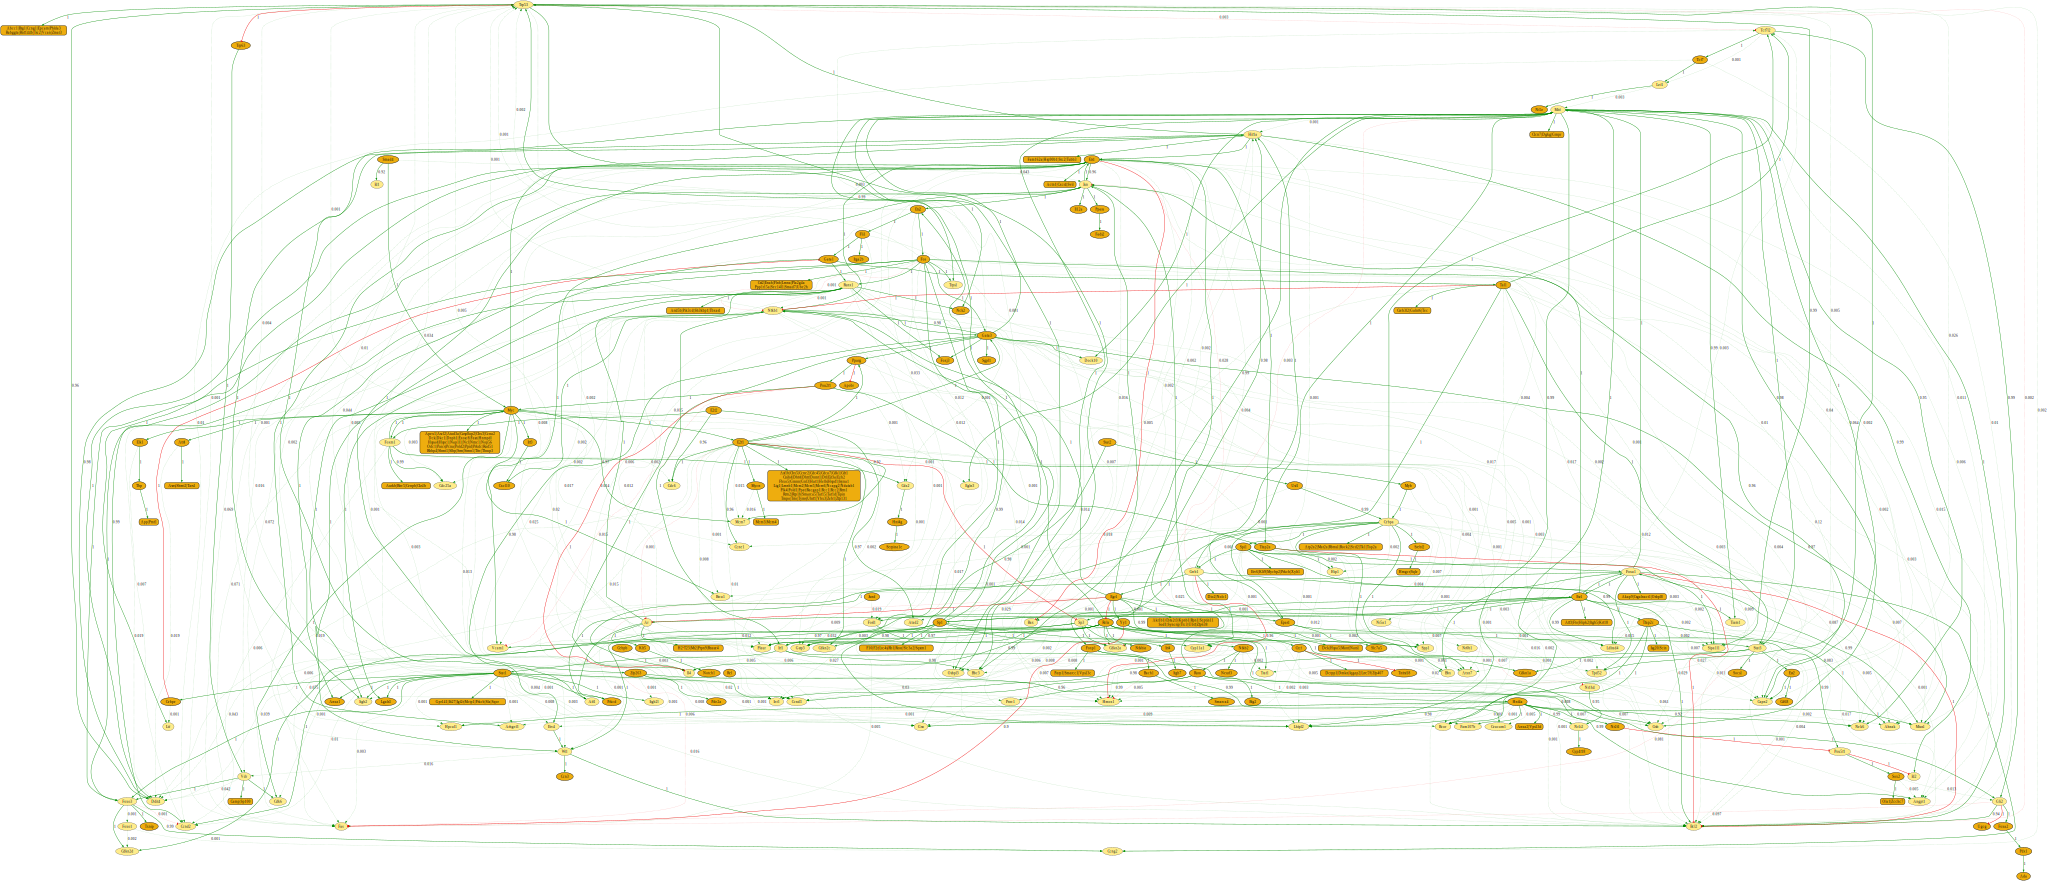

In [4]:
ig = bns.to_influence_graph()

function_family_options = {
    "collapse": "family",
    "drop_isolates": True,
    "edge_label": "frequency",
    "graph_attr": {
        "ratio": "compress",
        "overlap": "prism",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "ranksep": "1.0",
        "pack": "true",
        "rankdir": "TB",
        "splines": "curve",
    },
    "node_attr": {
        "fontsize": "20",
    },
    "node_style": "stability",
    "edge_attr": {
        "fontsize": "20",
    },
    "edge_style": "frequency",
}

ig.show(**function_family_options, width="100%")
ig.to_pydot(**function_family_options).write_pdf(
    str(FIGURE_DIR / "ig_function_families.pdf")
)

### Feedback core <a class="anchor" id="fig-feedback-core"></a>

Restricting the ensemble to feedback-associated components highlights the regulatory core most directly involved in the long-term dynamical behaviour.

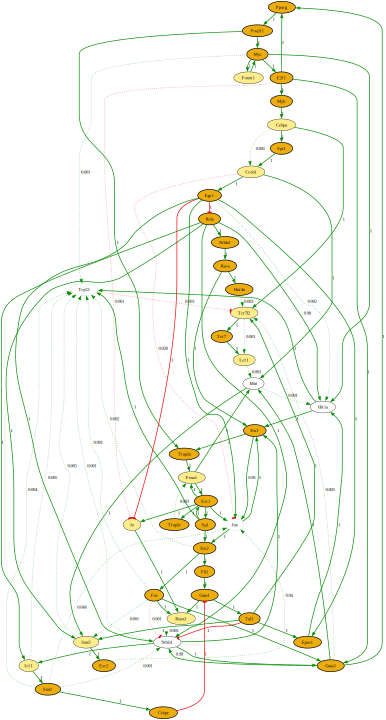

In [5]:
feedback_core_options = {
    "collapse": "both",
    "drop_isolates": True,
    "edge_label": "frequency",
    "node_style": "count",
    "preserve_feedback": True,
    "include_selfloops": False,
    "min_frequency": 0,
    "program": "dot",
    "graph_attr": {
        "ratio": "compress",
        "size": "10,10!",
        "rankdir": "TB",
        "splines": "curve",
        "ranksep": "0.25",
        "pack": "true",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "overlap": "prism",
    },
}

ig.show(**feedback_core_options)
ig.to_pydot(**feedback_core_options).write_pdf(str(FIGURE_DIR / "ig_feedback_core.pdf"))

## Gene selection enrichment analysis <a class="anchor" id="enrichment"></a>

The subset-minimal Boolean network components are tested for Gene Ontology enrichment using the mouse DoRothEA legacy prior network used by scBOLT as background. The GO basic ontology and NCBI gene-to-GO associations are downloaded on first use and cached in the operating system's temporary directory.

### Top enriched biological processes <a class="anchor" id="fig-goea-bp"></a>

The panel below reports the top 20 enriched biological process (BP) terms ranked by FDR. The following table retains the prespecified terms used elsewhere in the case study and reports their canonical GO names, enrichment statistics, raw p-values, and Benjamini-Hochberg-adjusted p-values. Terms absent from the GOEA results are kept with `NaN` statistics.

set,n
DoRothEA edges,15189
DoRothEA genes,5198
BoNesis components,523
GO-mapped BoNesis components,523
GO-mapped DoRothEA genes,5195


GO,name,p_fdr_bh,study_count,pop_count,minus_log10_fdr
GO:0000122,negative regulation of transcription by RNA polymerase II,5.53e-14,118,540,13.26
GO:0045893,positive regulation of DNA-templated transcription,2.33e-13,103,451,12.63
GO:0006355,regulation of DNA-templated transcription,4.07e-12,116,561,11.39
GO:0045944,positive regulation of transcription by RNA polymerase II,7.09e-11,132,704,10.15
GO:0006357,regulation of transcription by RNA polymerase II,6.17e-09,113,600,8.21
GO:0045892,negative regulation of DNA-templated transcription,3.10e-08,70,310,7.51
GO:1902895,positive regulation of miRNA transcription,8.24e-08,23,50,7.08
GO:0030154,cell differentiation,2.55e-05,48,208,4.59
GO:0042127,regulation of cell population proliferation,4.52e-05,37,144,4.34
GO:0051726,regulation of cell cycle,2.52e-04,33,129,3.60


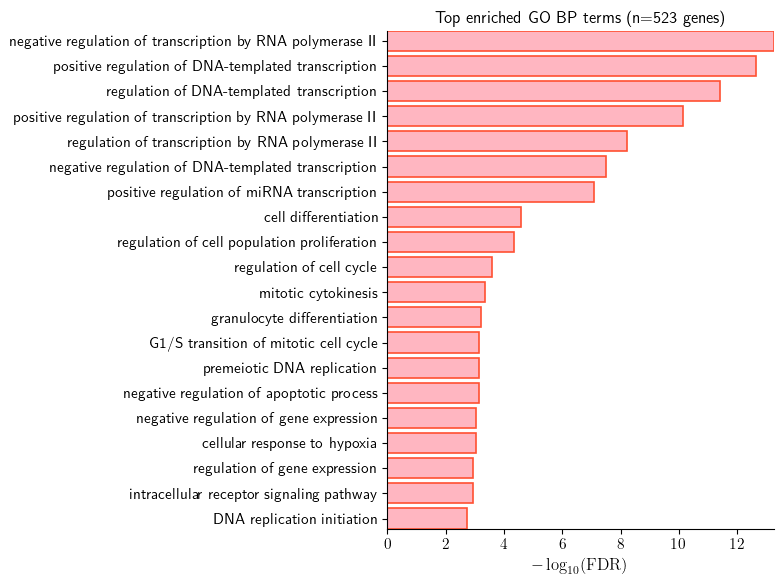

In [6]:
selected_genes = sorted(components)
prior_knowledge = bt.resources.omnipath.dorothea(
    organism="mouse",
    levels=DOROTHEA_LEVELS,
    identifiers=mouse_identifiers,
    version=OMNIPATH_VERSION,
    hcop_version=HCOP_VERSION,
    compatibility=DOROTHEA_COMPATIBILITY,
    flavor=DOROTHEA_API,
)
go_background = sorted(prior_knowledge.nodes)

selected_gene_ids = to_gene_ids(selected_genes, mouse_identifiers)
background_gene_ids = to_gene_ids(go_background, mouse_identifiers)
missing_gene_ids = selected_gene_ids - background_gene_ids

if missing_gene_ids:
    raise ValueError(
        f"{len(missing_gene_ids)} BoNesis component Gene IDs are absent from "
        "the DoRothEA background."
    )

display_counts(
    {
        "DoRothEA edges": prior_knowledge.number_of_edges(),
        "DoRothEA genes": len(go_background),
        "BoNesis components": len(selected_genes),
        "GO-mapped BoNesis components": len(selected_gene_ids),
        "GO-mapped DoRothEA genes": len(background_gene_ids),
    },
    index_name="set",
    count_name="n",
)

go_basic_file, gene2go_file = get_go_resources()

with open(os.devnull, "w") as log:
    go_dag = GODag(str(go_basic_file), prt=log)

associations = read_gene2go_associations(
    gene2go_file,
    gene_ids=background_gene_ids,
)

with open(os.devnull, "w") as log:
    goea = GOEnrichmentStudyNS(
        pop=background_gene_ids,
        ns2assoc=associations,
        godag=go_dag,
        propagate_counts=False,
        alpha=0.05,
        methods=["fdr_bh"],
        log=log,
    )

with open(os.devnull, "w") as log:
    goea_results = goea_results_dataframe(
        goea.run_study(study_ids=selected_gene_ids, log=log)
    )

bp_enrichment = (
    goea_results.query("NS == 'BP' and enrichment == 'e'")
    .sort_values("p_fdr_bh", kind="mergesort")
    .reset_index(drop=True)
)
top_bp_terms = bp_enrichment.head(20).copy()

if top_bp_terms.empty:
    raise ValueError("No enriched GO BP term found for the BoNesis components.")

top_bp_terms["minus_log10_fdr"] = -np.log10(
    top_bp_terms["p_fdr_bh"].clip(lower=np.finfo(float).tiny)
)

display(
    top_bp_terms[
        ["GO", "name", "p_fdr_bh", "study_count", "pop_count", "minus_log10_fdr"]
    ]
    .style.hide(axis="index")
    .format({"p_fdr_bh": "{:.2e}", "minus_log10_fdr": "{:.2f}"})
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = top_bp_terms.iloc[::-1]

ax.barh(
    plot_df["name"],
    plot_df["minus_log10_fdr"],
    color=bt.omics.pl.get_color("pink"),
    edgecolor=bt.omics.pl.get_color("red"),
    linewidth=1.2,
)
ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$", fontsize=12)
ax.set_ylabel(None)
ax.set_title(
    f"Top enriched GO BP terms (n={len(selected_genes)} genes)",
    fontsize=12,
)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "bn_goea_bp_top20.pdf", bbox_inches="tight")
plt.show()
plt.close()

## Pairwise macrostate distances <a class="anchor" id="distances"></a>

Pairwise distance matrix between macrostates based on the selected Boolean-network components. Each distance is the number of components that are defined in both macrostates and assigned different Boolean values. The corresponding maximum observable distance is the number of components defined in both macrostates, independently of whether their values match or differ. Pairwise similarity can therefore be computed as the maximum observable distance minus the observed distance.

In [7]:
distance = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_distance),
)
maximum = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_maximum),
)

distance_upper = upper_triangle(distance)
maximum_upper = upper_triangle(maximum)

display(
    distance_upper.style.set_caption("Pairwise macrostate distances").format(
        "{:.0f}", na_rep=""
    )
)
display(
    maximum_upper.style.set_caption(
        "Jointly binarised genes per macrostate pair"
    ).format("{:.0f}", na_rep="")
)

## Boolean-network diversity <a class="anchor" id="model-diversity"></a>

### Functional model space <a class="anchor" id="fig-model-mds"></a>

Pairwise semantic Hamming distances quantify the mean fraction of Boolean input configurations on which corresponding update functions disagree. Unlike a binary equivalence score, this metric preserves the magnitude of each functional difference.

Multidimensional scaling (MDS) projects these distances into two dimensions. A deterministic three-group k-means partition mirrors the exploratory presentation of Chevalier *et al.*; the colours describe regions of the projection and are not assigned biological identities.

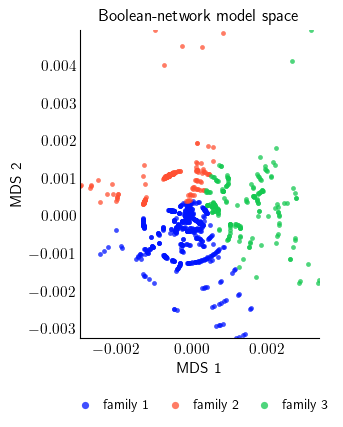

In [8]:
bn_hamming_distances = bns.distance(metric="hamming")
bn_mds = MDS(
    n_components=2,
    metric="precomputed",
    init="classical_mds",
    n_init=1,
    random_state=0,
    normalized_stress="auto",
).fit_transform(bn_hamming_distances)

n_model_families = 3
model_families = KMeans(
    n_clusters=n_model_families,
    n_init=20,
    random_state=0,
).fit_predict(bn_mds)
family_colors = bt.omics.pl.get_palette("classic").colors[:n_model_families]

fig, ax = plt.subplots(figsize=(5, 4.5))
for family, color in enumerate(family_colors):
    members = model_families == family
    ax.scatter(
        bn_mds[members, 0],
        bn_mds[members, 1],
        color=color,
        s=12,
        alpha=0.75,
        linewidths=0,
        label=f"family {family + 1}",
    )

ax.set(
    title="Boolean-network model space",
    xlabel="MDS 1",
    ylabel="MDS 2",
)
ax.title.set_fontsize(12)
ax.xaxis.label.set_fontsize(11)
ax.yaxis.label.set_fontsize(11)
ax.set_aspect("equal", adjustable="box")
ax.tick_params(length=0, labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    borderaxespad=0,
    ncol=3,
    columnspacing=0.8,
    handletextpad=0.3,
    frameon=False,
    fontsize=10,
    markerscale=1.5,
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "bn_mds.pdf", bbox_inches="tight")
plt.show()
plt.close()

## Reachable attractors <a class="anchor" id="attractors"></a>

### Ensemble distributions <a class="anchor" id="fig-attractor-distributions"></a>

For each Boolean network, we count all minimal trap spaces. We then directly recover the trap-space hypercubes of the most-permissive attractors reachable from the inferred `ctrl_Prom1` and `treated_Prom1` configurations. Within each reachable landscape, attractors are classified by compatibility with the corresponding terminal macrostates. Compatibility means that no jointly fixed component has conflicting values; it does not require the attractor and macrostate to be identical.

The resulting distributions separate landscape complexity from terminal-state identity. The same classified attractors are reused below for comparison with the reference APL model.

In [9]:
attractor_landscapes = {
    "ctrl_Prom1": ["ctrl_Rep", "ctrl_Alt", "ctrl_Neu"],
    "treated_Prom1": ["treated_Rep", "treated_Neu"],
}

minimal_trapspace_counts = []
prom1_reachable_attractor_counts = {
    initial_state: [] for initial_state in attractor_landscapes
}
scbolt_reachable_attractors = {
    terminal_state: []
    for terminal_states in attractor_landscapes.values()
    for terminal_state in terminal_states
}
scbolt_reachable_attractor_counts = {
    terminal_state: [] for terminal_state in scbolt_reachable_attractors
}

for bn, config in zip(bns, configs):
    minimal_trapspace_counts.append(len(bn.trap_spaces()))

    for initial_state, terminal_states in attractor_landscapes.items():
        reachable_attractors = [
            attractor.hypercubes()[0]
            for attractor in bn.attractors(
                config[initial_state],
                update="most-permissive",
            )
        ]
        prom1_reachable_attractor_counts[initial_state].append(
            len(reachable_attractors)
        )

        for terminal_state in terminal_states:
            matching_attractors = [
                attractor
                for attractor in reachable_attractors
                if hypercubes_are_compatible(
                    attractor, mstate_hypercubes[terminal_state]
                )
            ]
            scbolt_reachable_attractors[terminal_state].extend(
                matching_attractors
            )
            scbolt_reachable_attractor_counts[terminal_state].append(
                len(matching_attractors)
            )

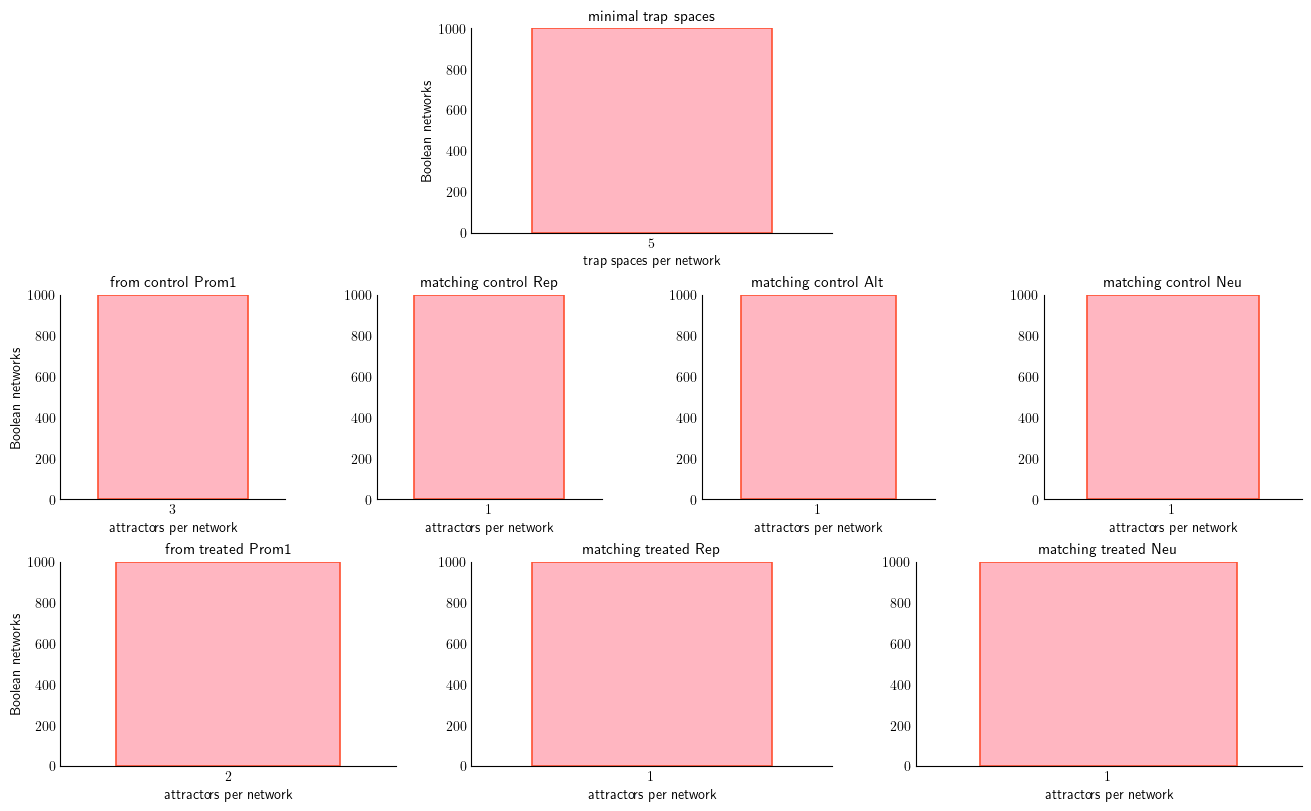

In [10]:
figure_layout = [
    ["."] * 4 + ["trap"] * 4 + ["."] * 4,
    ["ctrl_reachable"] * 3 + ["ctrl_rep"] * 3 + ["ctrl_alt"] * 3 + ["ctrl_neu"] * 3,
    ["treated_reachable"] * 4 + ["treated_rep"] * 4 + ["treated_neu"] * 4,
]
fig, axes = plt.subplot_mosaic(
    figure_layout,
    figsize=(13, 8),
    constrained_layout=True,
)

panels = {
    "trap": (
        minimal_trapspace_counts,
        "minimal trap spaces",
        "trap spaces per network",
    ),
    "ctrl_reachable": (
        prom1_reachable_attractor_counts["ctrl_Prom1"],
        "from control Prom1",
        "attractors per network",
    ),
    "ctrl_rep": (
        scbolt_reachable_attractor_counts["ctrl_Rep"],
        "matching control Rep",
        "attractors per network",
    ),
    "ctrl_alt": (
        scbolt_reachable_attractor_counts["ctrl_Alt"],
        "matching control Alt",
        "attractors per network",
    ),
    "ctrl_neu": (
        scbolt_reachable_attractor_counts["ctrl_Neu"],
        "matching control Neu",
        "attractors per network",
    ),
    "treated_reachable": (
        prom1_reachable_attractor_counts["treated_Prom1"],
        "from treated Prom1",
        "attractors per network",
    ),
    "treated_rep": (
        scbolt_reachable_attractor_counts["treated_Rep"],
        "matching treated Rep",
        "attractors per network",
    ),
    "treated_neu": (
        scbolt_reachable_attractor_counts["treated_Neu"],
        "matching treated Neu",
        "attractors per network",
    ),
}

for panel, (values, title, xlabel) in panels.items():
    plot_discrete_distribution(
        values,
        ax=axes[panel],
        title=title,
        xlabel=xlabel,
    )

for row in (
    ["ctrl_reachable", "ctrl_rep", "ctrl_alt", "ctrl_neu"],
    ["treated_reachable", "treated_rep", "treated_neu"],
):
    ymax = max(axes[panel].get_ylim()[1] for panel in row)
    for panel in row:
        axes[panel].set_ylim(0, ymax)

for panel in ("trap", "ctrl_reachable", "treated_reachable"):
    axes[panel].set_ylabel("Boolean networks", fontsize=10)

plt.savefig(FIGURE_DIR / "bn_attractor_distributions.pdf", bbox_inches="tight")
plt.show()
plt.close()

Across the 1,000 networks, 616 contain 8 minimal trap spaces and 384 contain 16. Every control landscape contains four attractors reachable from `ctrl_Prom1`: two match `ctrl_Rep`, one matches `ctrl_Alt`, and one matches `ctrl_Neu`. Every treated landscape contains two attractors reachable from `treated_Prom1`, split between `treated_Rep` and `treated_Neu`.

## Reference APL model attractors <a class="anchor" id="reference-model"></a>

The Sanchez-Villanueva APL model is downloaded from the public GINsim model page at runtime and kept in a local cache ignored by git. The original model uses human gene symbols and several model-level variables or complexes; those non-gene components are protected before translation. Gene-like components in both the Boolean network and its influence graph are standardised with human NCBI GENEINFO, translated to mouse with HCOP, and standardised again with mouse NCBI GENEINFO.

The attractors below are computed with fully asynchronous semantics from the three `PLZF_RARA_*` initial states encoded directly in the published model, matching the update scheme used in the original study. These configurations set the fusion-gene inputs (`PLZF_RARAg=1`, `PML_RARAg=0`) and the corresponding ATRA level, while the fusion-protein components evolve according to the model rules. Components without a clean counterpart in the scBOLT states are reported rather than coerced. The `CDK4_6` family component is compared with `Cdk4` and/or `Cdk6` when either family member is retained by the scBOLT inference.

### Phenotype signatures

Phenotype signatures follow the representative components used to annotate stable states in Figure 4 of the Sanchez-Villanueva study. Their original human identifiers are mapped through the translated influence graph so that the signatures and Boolean network use the same mouse symbols. The six context-specific results are then grouped by their internal state after excluding model inputs, yielding three attractors labelled `T1` to `T3`.

An attractor matches a signature when all its representative components are fixed to `1`. Because the differentiated attractor also activates the cell-cycle-arrest markers, phenotypes are assigned with the priority `differentiated`, `arrested`, then `proliferative`, reproducing the labels in Figure 4. Consequently, `T1` is proliferative, `T2` is arrested, and `T3` is differentiated. As ATRA increases, the arrested state is replaced by the differentiated state while the resistant proliferative state remains accessible.

### Reference-model attractor comparison <a class="anchor" id="fig-reference-model"></a>

The three internal reference-model attractors are compared with the terminal-compatible scBOLT attractors identified above from the `ctrl_Prom1` and `treated_Prom1` landscapes. All gene-level components shared by the translated reference model and the scBOLT networks are included automatically, then grouped according to the `Proliferation`, `Arrest`, `Differentiation`, and `Epigenetic` node styles encoded in the published GINsim model. A component is shown as `0` or `1` only when every matching attractor across the ensemble agrees; otherwise it remains undefined. The scBOLT `Rep` and `Neu` states respectively provide the closest proliferative and differentiated counterparts. `Alt` is retained as a distinct terminal state with a less direct, partly arrest-like interpretation. In the scBOLT rows, square markers denote values already fixed in `mstates_bin.csv`, while circles denote values fixed only by the reachable-attractor consensus.


phenotype,components
proliferative,"E2f1, Myc"
arrested,"Cdkn1a, Cdkn1b, Trp53"
differentiated,"Spi1, CEBPAB, Rarb"


attractor,phenotype,accessible from
T1,proliferative,"no ATRA, physiological ATRA, pharmacological ATRA"
T2,arrested,no ATRA
T3,differentiated,"physiological ATRA, pharmacological ATRA"


item,n
reference-model components,37
maximum comparable genes,28
common genes,16
unique internal attractors,3
attractors from no ATRA,2
attractors from physiological ATRA,2
attractors from pharmacological ATRA,2


reference component,scBOLT component
CDK4_6,Cdk6


state,attractors,min per BN,max per BN,BNs with multiple,universally fixed components
ctrl_Rep,1000,1,1,0,507
ctrl_Alt,1000,1,1,0,504
ctrl_Neu,1000,1,1,0,489
treated_Rep,1000,1,1,0,500
treated_Neu,1000,1,1,0,512


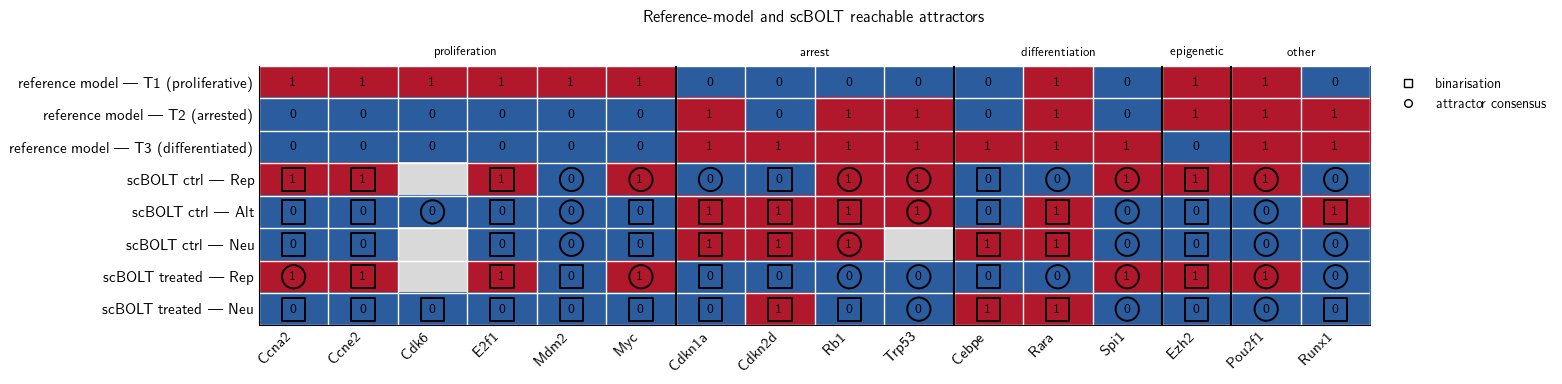

In [11]:
reference_model_file = download_if_missing(
    REFERENCE_MODEL_URL,
    REFERENCE_MODEL_FILE,
)
reference_model = bt.logic.io.read_zginml(reference_model_file)
reference_bn, reference_ig = translate_reference_model(reference_model)

reference_initial_conditions = reference_model.initial_conditions()
reference_initial_states = {
    label: reference_initial_conditions[f"PLZF_RARA_{suffix}"]
    for suffix, label in REFERENCE_MODEL_ATRA_LABELS.items()
}

reference_attractors = {
    name: [
        attractor.enumerate()[0]
        for attractor in reference_bn.attractors(
            input_state,
            update="asynchronous",
        )
    ]
    for name, input_state in reference_initial_states.items()
}

reference_component_names = {
    attributes["reference_component"]: component
    for component, attributes in reference_ig.nodes(data=True)
}
reference_phenotypes = {
    phenotype: [
        reference_component_names[component] for component in reference_components
    ]
    for phenotype, reference_components in REFERENCE_MODEL_PHENOTYPES.items()
}

display(
    pd.DataFrame(
        [
            {"phenotype": phenotype, "components": ", ".join(components)}
            for phenotype, components in reference_phenotypes.items()
        ]
    ).style.hide(axis="index")
)

reference_input_components = {
    component
    for component, attributes in reference_ig.nodes(data=True)
    if attributes.get("input", False)
}
unique_reference_attractor_states = []
reference_attractor_accessibility = defaultdict(list)

for initial_state, attractors in reference_attractors.items():
    for attractor in attractors:
        internal_state = {
            component: value
            for component, value in attractor.items()
            if component not in reference_input_components
        }
        if internal_state not in unique_reference_attractor_states:
            unique_reference_attractor_states.append(internal_state)

        attractor_label = (
            f"T{unique_reference_attractor_states.index(internal_state) + 1}"
        )
        reference_attractor_accessibility[attractor_label].append(initial_state)

reference_unique_attractors = {
    f"T{index}": attractor
    for index, attractor in enumerate(unique_reference_attractor_states, start=1)
}
reference_attractor_phenotypes = {
    attractor_label: next(
        (
            phenotype
            for phenotype in REFERENCE_MODEL_PHENOTYPE_PRIORITY
            if all(
                attractor.get(component) == 1
                for component in reference_phenotypes[phenotype]
            )
        ),
        "unclassified",
    )
    for attractor_label, attractor in reference_unique_attractors.items()
}

reference_attractor_summary = pd.DataFrame(
    [
        {
            "attractor": attractor_label,
            "phenotype": reference_attractor_phenotypes[attractor_label],
            "accessible from": ", ".join(
                reference_attractor_accessibility[attractor_label]
            ),
        }
        for attractor_label in reference_unique_attractors
    ]
)
display(reference_attractor_summary.style.hide(axis="index"))

reference_genes = set(mouse_identifiers.find(*reference_bn))
reference_family_genes = {
    gene
    for component, genes in REFERENCE_MODEL_SC_BOLT_COMPONENTS.items()
    if component in reference_bn
    for gene in genes
}
comparable_reference_genes = reference_genes | reference_family_genes
common_reference_genes = comparable_reference_genes & set(components)

reference_panel_columns, mapped_panel_components = build_reference_panel_columns(
    reference_bn,
    reference_ig,
    components,
    reference_genes,
)

display_counts(
    {
        "reference-model components": len(reference_bn),
        "maximum comparable genes": len(comparable_reference_genes),
        "common genes": len(common_reference_genes),
        "unique internal attractors": len(unique_reference_attractor_states),
        **{
            f"attractors from {name}": len(attractors)
            for name, attractors in reference_attractors.items()
        },
    },
    index_name="item",
    count_name="n",
)

if mapped_panel_components:
    display(
        pd.DataFrame(
            mapped_panel_components,
            columns=["reference component", "scBOLT component"],
        ).style.hide(axis="index")
    )

reachable_attractor_summary = pd.DataFrame(
    [
        {
            "state": state_name,
            "attractors": len(scbolt_reachable_attractors[state_name]),
            "min per BN": min(scbolt_reachable_attractor_counts[state_name]),
            "max per BN": max(scbolt_reachable_attractor_counts[state_name]),
            "BNs with multiple": sum(
                count > 1 for count in scbolt_reachable_attractor_counts[state_name]
            ),
            "universally fixed components": sum(
                not pd.isna(
                    consensus_attractor_value(
                        scbolt_reachable_attractors,
                        state_name,
                        component,
                    )
                )
                for component in components
            ),
        }
        for state_name in SCBOLT_TERMINAL_STATES.values()
    ]
)
display(reachable_attractor_summary.style.hide(axis="index"))

reference_comparison_states = {
    f"{attractor_label} ({reference_attractor_phenotypes[attractor_label]})": attractor
    for attractor_label, attractor in reference_unique_attractors.items()
}
reference_state_table, reference_state_origin = reference_state_comparison_table(
    reference_comparison_states,
    scbolt_reachable_attractors,
    mstate_hypercubes,
    reference_panel_columns,
)

display(
    reference_state_table.style.set_caption(
        "Reference-model and scBOLT reachable-attractor consensus"
    ).format("{:.0f}", na_rep="")
)

fig, ax = plot_binary_state_table(reference_state_table, reference_state_origin)
ax.set_title(
    "Reference-model and scBOLT reachable attractors",
    fontsize=12,
    pad=32,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "reference_model_state_comparison.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [12]:
# Rank interventions that selectively remove reachable Rep attractors.

# Perturbed attractors may move within the state space. They are therefore
# compared through their nearest unperturbed minimal trap spaces rather than
# through exact hypercube equality.

from collections import defaultdict

from tqdm.auto import tqdm


landscapes = {
    "ctrl": ("ctrl_Prom1", "ctrl_Rep"),
    "treated": ("treated_Prom1", "treated_Rep"),
}
function_core = tuple(sorted(ig.feedback_nodes(include_selfloops=False)))


def nearest_reference_indices(
    attractor,
    references,
    *,
    excluded_component,
):
    distances = []

    for reference_index, reference in enumerate(references):
        changes = reference.changes(attractor)
        distance = (
            2 * len(changes.flips)
            + len(changes.stabilizations)
            + len(changes.destabilizations)
        )
        if excluded_component in changes.flips:
            distance -= 2
        elif (
            excluded_component in changes.stabilizations
            or excluded_component in changes.destabilizations
        ):
            distance -= 1
        distances.append((distance, reference_index))

    minimum_distance = min(distance for distance, _ in distances)

    return {
        reference_index
        for distance, reference_index in distances
        if distance == minimum_distance
    }


intervention_statistics = defaultdict(
    lambda: {
        "score": 0.0,
        "full_rep_loss": 0,
        "partial_rep_loss": 0,
        "condition_preserved": 0,
        "off_target": 0,
        "eligible_networks": 0,
    }
)
reference_attractors_by_network = [None] * len(bns)

for condition, (initial_state, rep_state) in landscapes.items():
    for network_index, (bn, config) in enumerate(
        tqdm(
            zip(bns, configs),
            total=len(bns),
            desc=f"Scoring {condition} targets",
        )
    ):
        references = reference_attractors_by_network[network_index]
        if references is None:
            references = tuple(sorted(bn.trap_spaces(), key=repr))
            reference_attractors_by_network[network_index] = references
        baseline_attractors = tuple(
            attractor.hypercubes()[0]
            for attractor in bn.attractors(
                config[initial_state],
                update="most-permissive",
            )
        )
        baseline_indices = {
            next(
                index
                for index, reference in enumerate(references)
                if reference == attractor
            )
            for attractor in baseline_attractors
        }
        rep_indices = {
            index
            for index in baseline_indices
            if hypercubes_are_compatible(
                references[index],
                mstate_hypercubes[rep_state],
            )
        }
        other_indices = baseline_indices - rep_indices

        for component in function_core:
            for constant in (0, 1):
                statistics = intervention_statistics[
                    condition,
                    component,
                    constant,
                ]

                if not rep_indices:
                    continue

                statistics["eligible_networks"] += 1

                perturbed_bn = bn.copy()
                perturbed_bn[component] = constant
                perturbed_attractors = (
                    attractor.hypercubes()[0]
                    for attractor in perturbed_bn.attractors(
                        config[initial_state],
                        update="most-permissive",
                    )
                )

                mapped_indices = set()
                for attractor in perturbed_attractors:
                    mapped_indices.update(
                        nearest_reference_indices(
                            attractor,
                            references,
                            excluded_component=component,
                        )
                    )

                condition_preserved = (
                    other_indices <= mapped_indices <= baseline_indices
                )
                if not condition_preserved:
                    statistics["off_target"] += 1
                    continue

                statistics["condition_preserved"] += 1
                rep_loss = len(rep_indices - mapped_indices) / len(rep_indices)
                statistics["score"] += rep_loss

                if rep_loss == 1.0:
                    statistics["full_rep_loss"] += 1
                elif rep_loss > 0.0:
                    statistics["partial_rep_loss"] += 1


therapeutic_target_scores = pd.DataFrame(
    [
        {
            "condition": condition,
            "gene": component,
            "constant": constant,
            **statistics,
        }
        for (
            condition,
            component,
            constant,
        ), statistics in intervention_statistics.items()
    ]
).sort_values(
    [
        "condition",
        "score",
        "full_rep_loss",
        "partial_rep_loss",
        "off_target",
    ],
    ascending=[True, False, False, False, True],
    ignore_index=True,
)

top_therapeutic_targets = (
    therapeutic_target_scores.groupby("condition", sort=False)
    .head(20)
    .reset_index(drop=True)
)


for condition in landscapes:
    print(
        f"Top {condition} interventions among {len(function_core)} "
        "feedback-core genes"
    )
    display(
        top_therapeutic_targets.loc[
            top_therapeutic_targets["condition"].eq(condition)
        ].reset_index(drop=True)
    )


Scoring ctrl targets:   0%|          | 0/1000 [00:00<?, ?it/s]

Scoring treated targets:   0%|          | 0/1000 [00:00<?, ?it/s]

Top ctrl interventions among 42 feedback-core genes


,condition,gene,constant,score,full_rep_loss,partial_rep_loss,condition_preserved,off_target,eligible_networks
0,ctrl,Foxm1,0,1000.0,1000,0,1000,0,1000
1,ctrl,Pparg,0,1000.0,1000,0,1000,0,1000
2,ctrl,Fos,0,999.0,999,0,1000,0,1000
3,ctrl,Gata3,0,945.0,945,0,945,55,1000
4,ctrl,E2f1,0,871.0,871,0,871,129,1000
5,ctrl,Myc,0,871.0,871,0,871,129,1000
6,ctrl,Pou2f1,0,871.0,871,0,871,129,1000
7,ctrl,Ar,0,0.0,0,0,1000,0,1000
8,ctrl,Ar,1,0.0,0,0,1000,0,1000
9,ctrl,Epas1,0,0.0,0,0,1000,0,1000


Top treated interventions among 42 feedback-core genes


,condition,gene,constant,score,full_rep_loss,partial_rep_loss,condition_preserved,off_target,eligible_networks
0,treated,E2f1,0,1000.0,1000,0,1000,0,1000
1,treated,Foxm1,0,1000.0,1000,0,1000,0,1000
2,treated,Gata3,0,1000.0,1000,0,1000,0,1000
3,treated,Myc,0,1000.0,1000,0,1000,0,1000
4,treated,Nfkb1,0,1000.0,1000,0,1000,0,1000
5,treated,Pou2f1,0,1000.0,1000,0,1000,0,1000
6,treated,Pparg,0,1000.0,1000,0,1000,0,1000
7,treated,Tal1,1,999.0,999,0,1000,0,1000
8,treated,Myb,0,997.0,997,0,1000,0,1000
9,treated,Fli1,1,997.0,997,0,998,2,1000
